# Prompt chaining

Prompt chaining is when each LLM call processes the output of the previous call. It’s often used for performing well-defined tasks that can be broken down into smaller, verifiable steps. Some examples include:

* Translating documents into different languages
* Verifying generated content for consistency

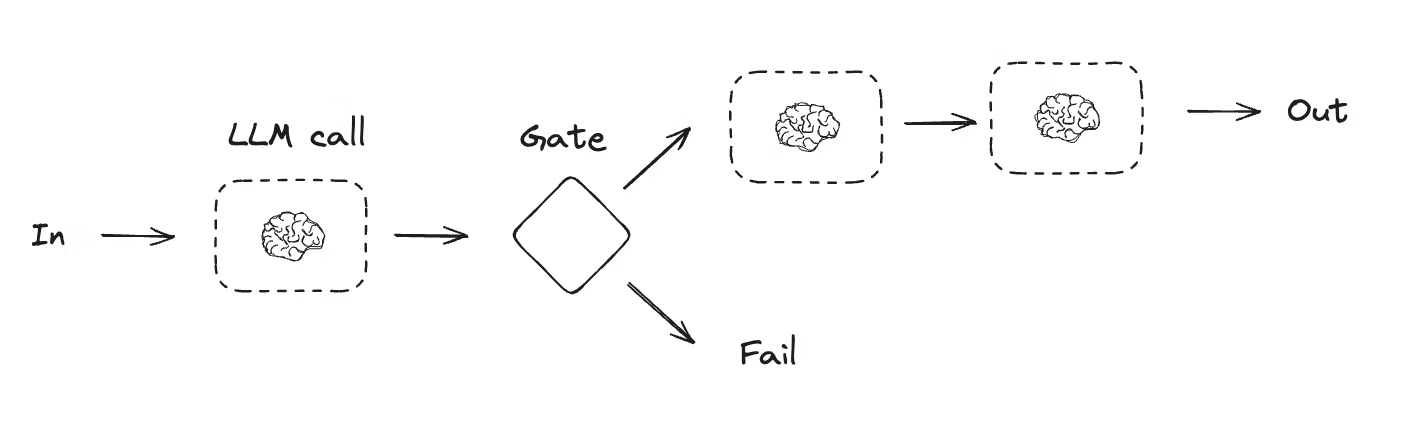

In [2]:
import os
from dotenv import load_dotenv

load_dotenv()

os.environ["ANTHROPIC_API_KEY"] = os.getenv("ANTHROPIC_API_KEY")

from langchain.chat_models import init_chat_model

llm = init_chat_model("claude-haiku-4-5", temperature=0, max_tokens=100)

## By using the Graph API

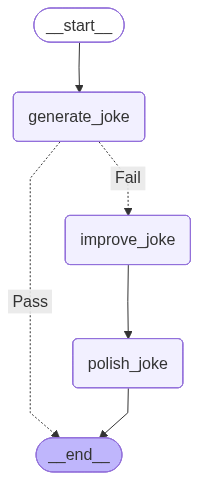

Initial joke:
Here's one:

**Why don't cats play poker in the jungle?**

Too many cheetahs! 🐱

*(Okay, the cheetah's not technically a cat... but your cat would still judge you for laughing.)* 😄

--- --- ---

Final joke:
Here's one:

**Why don't cats play poker in the jungle?**

Too many cheetahs! 🐱

*(Okay, the cheetah's not technically a cat... but your cat would still judge you for laughing.)* 😄


In [4]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display


# Graph state
class State(TypedDict):
    topic: str
    joke: str
    improved_joke: str
    final_joke: str


# Nodes
def generate_joke(state: State):
    """First LLM call to generate initial joke"""

    msg = llm.invoke(f"Write a short joke about {state['topic']}")
    return {"joke": msg.content}


def check_punchline(state: State):
    """Gate function to check if the joke has a punchline"""

    # Simple check - does the joke contain "?" or "!"
    if "?" in state["joke"] or "!" in state["joke"]:
        return "Pass"
    return "Fail"


def improve_joke(state: State):
    """Second LLM call to improve the joke"""

    msg = llm.invoke(f"Make this joke funnier by adding wordplay: {state['joke']}")
    return {"improved_joke": msg.content}


def polish_joke(state: State):
    """Third LLM call for final polish"""
    msg = llm.invoke(f"Add a surprising twist to this joke: {state['improved_joke']}")
    return {"final_joke": msg.content}


# Build workflow
workflow = StateGraph(State)

# Add nodes
workflow.add_node("generate_joke", generate_joke)
workflow.add_node("improve_joke", improve_joke)
workflow.add_node("polish_joke", polish_joke)

# Add edges to connect nodes
workflow.add_edge(START, "generate_joke")
workflow.add_conditional_edges(
    "generate_joke", check_punchline, {"Fail": "improve_joke", "Pass": END}
)
workflow.add_edge("improve_joke", "polish_joke")
workflow.add_edge("polish_joke", END)

# Compile
chain = workflow.compile()

# Show workflow
display(Image(chain.get_graph().draw_mermaid_png()))

# Invoke
state = chain.invoke({"topic": "cats"})
print("Initial joke:")
print(state["joke"])
print("\n--- --- ---\n")
if "improved_joke" in state:
    print("Improved joke:")
    print(state["improved_joke"])
    print("\n--- --- ---\n")

    print("Final joke:")
    print(state["final_joke"])
else:
    print("Final joke:")
    print(state["joke"])

## By using the Functional API

In [6]:
from langgraph.func import entrypoint, task


# Tasks
@task
def generate_joke(topic: str):
    """First LLM call to generate initial joke"""
    msg = llm.invoke(f"Write a short joke about {topic}")
    return msg.content


def check_punchline(joke: str):
    """Gate function to check if the joke has a punchline"""
    # Simple check - does the joke contain "?" or "!"
    if "?" in joke or "!" in joke:
        return "Fail"

    return "Pass"


@task
def improve_joke(joke: str):
    """Second LLM call to improve the joke"""
    msg = llm.invoke(f"Make this joke funnier by adding wordplay: {joke}")
    return msg.content


@task
def polish_joke(joke: str):
    """Third LLM call for final polish"""
    msg = llm.invoke(f"Add a surprising twist to this joke: {joke}")
    return msg.content


@entrypoint()
def prompt_chaining_workflow(topic: str):
    original_joke = generate_joke(topic).result()
    if check_punchline(original_joke) == "Pass":
        return original_joke

    improved_joke = improve_joke(original_joke).result()
    return polish_joke(improved_joke).result()


# Invoke
for step in prompt_chaining_workflow.stream("cats", stream_mode="updates"):
    print(step)
    print("\n")

{'generate_joke': "Here's one:\n\n**Why don't cats play poker in the jungle?**\n\nToo many cheetahs! 🐱\n\n*(Okay, the cheetah's not technically a cat... but your cat will still judge you for laughing.)* 😄"}


{'improve_joke': "# Why Don't Cats Play Poker in the Jungle?\n\n**Too many cheetahs!** 🐆\n\n*And the lions kept **mane**-handling the deck...*\n\n*The leopards were always **spot**-ting everyone's cards...*\n\n*And the tigers? Total **stripe**-rs — they'd bluff every single hand.*\n\n*The house eventually had to **paws** the whole tournament.* "}


{'polish_joke': "# Why Don't Cats Play Poker in the Jungle?\n\n**Too many cheetahs!** 🐆\n\n*And the lions kept **mane**-handling the deck...*\n\n*The leopards were always **spot**-ting everyone's cards...*\n\n*And the tigers? Total **stripe**-rs — they'd bluff every single hand.*\n\n*The house eventually had to **paws** the whole tournament.*\n\n---"}


{'prompt_chaining_workflow': "# Why Don't Cats Play Poker in the Jungle?\n\n**Too ma